# Network Science Assignment 7

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 11. November 2024

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import numpy as np
import random
from tqdm import tqdm
import igraph as ig


In [3]:
def initialize_figure(ROWS, COLS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(8 * COLS, 8 * ROWS))
    axes = axes.flatten()
    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

def clean_figure(fig, axes, start, end):
    for i in range(start, end):
        fig.delaxes(axes[i])


In [7]:
# load the data
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1
Generate synthetic networks:
- Random networks (Erdos–Rényi) (with n= 1000 and ⟨k⟩ = {1,4})
- Scale‑free networks (Barabási‑Albert) (with n=1000 and m= {2,4})

In [10]:
n = 1000
# generate erdos renyi
# given k: p = (k/(n-1))
er_graphs = {k: nx.erdos_renyi_graph(n, k/(n-1)) for k in [1,4]}
# generate barabasi_albert
ba_graphs = {k: nx.barabasi_albert_graph(n, k) for k in [2,4]}

## Task 2
Plot the degree distributions of the synthetic networks and of the networks provided in the
datasets

### Comments
The degree distributions of the Erdös-Renyi networks are plotted in linear scale and according binning, while the Barabasi-Albert networks and the provided datasets are plotted using logarithmic binning and scale.

Text(0.5, 0.95, 'Task 2 - Datasets')

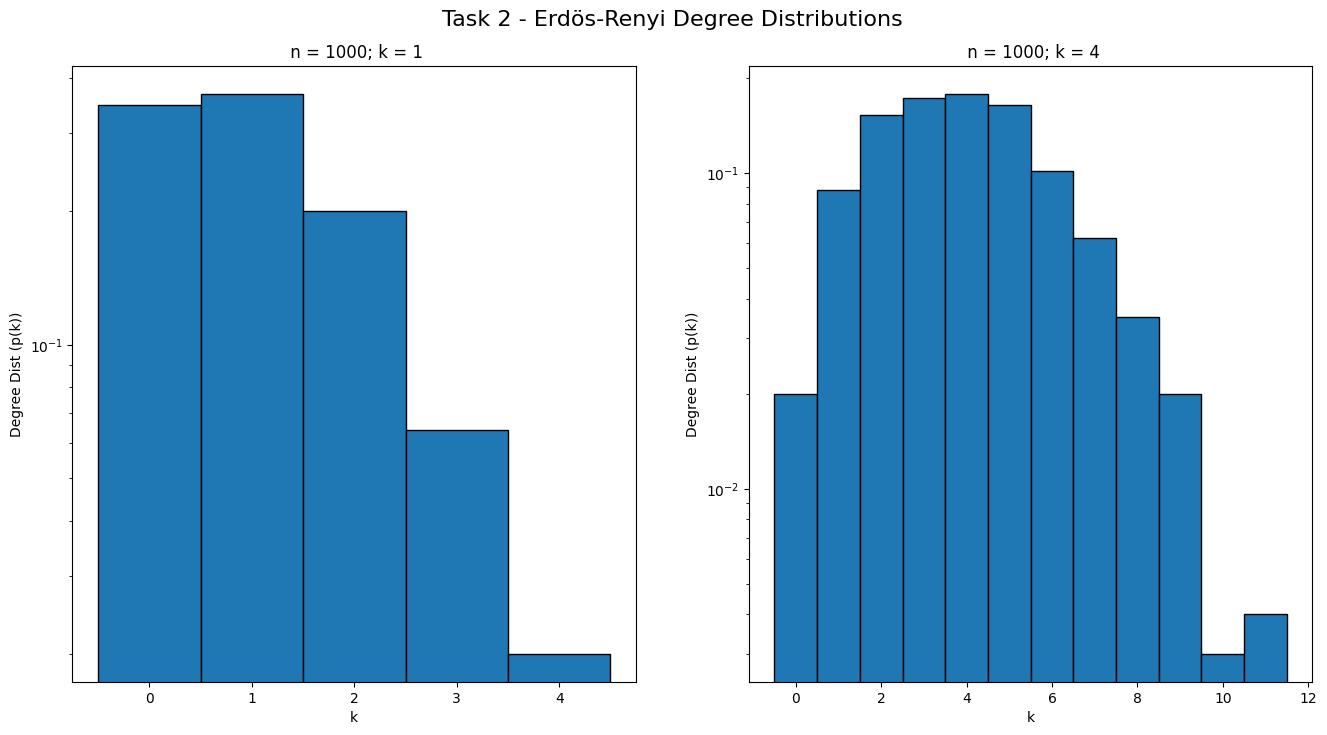

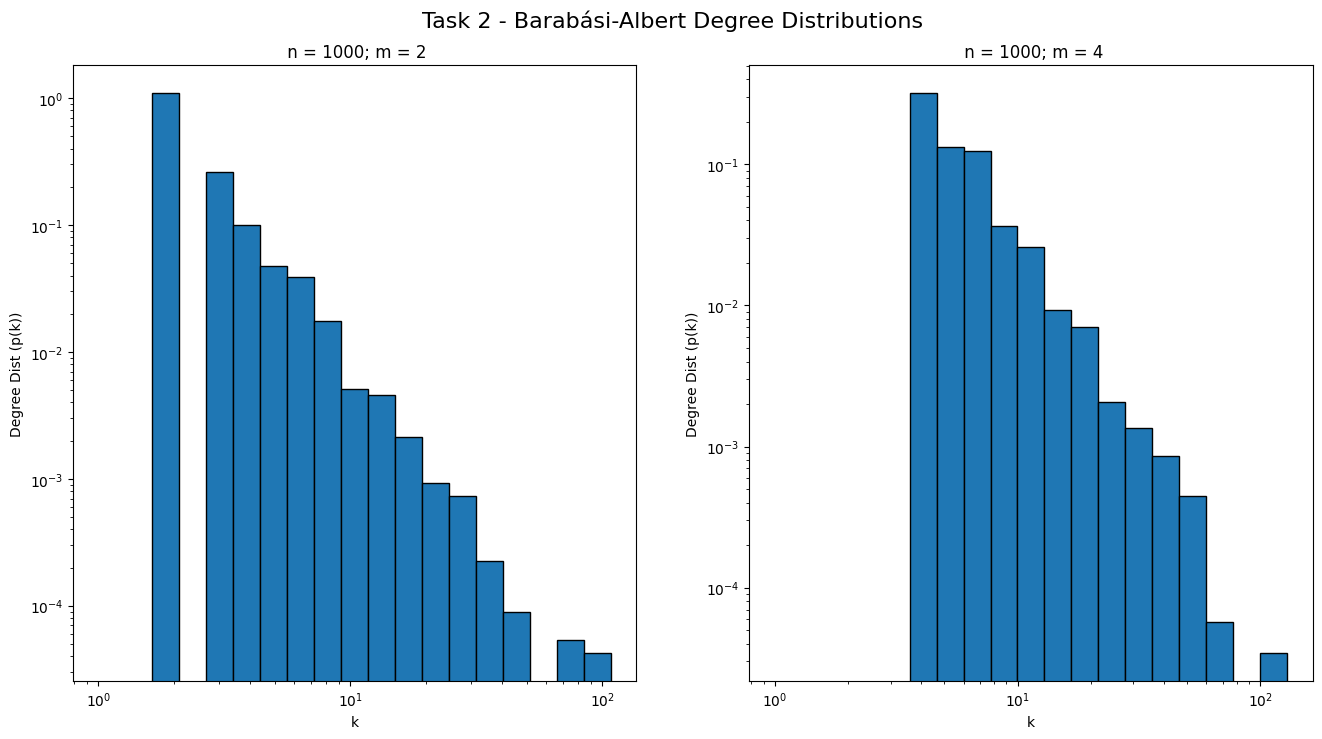

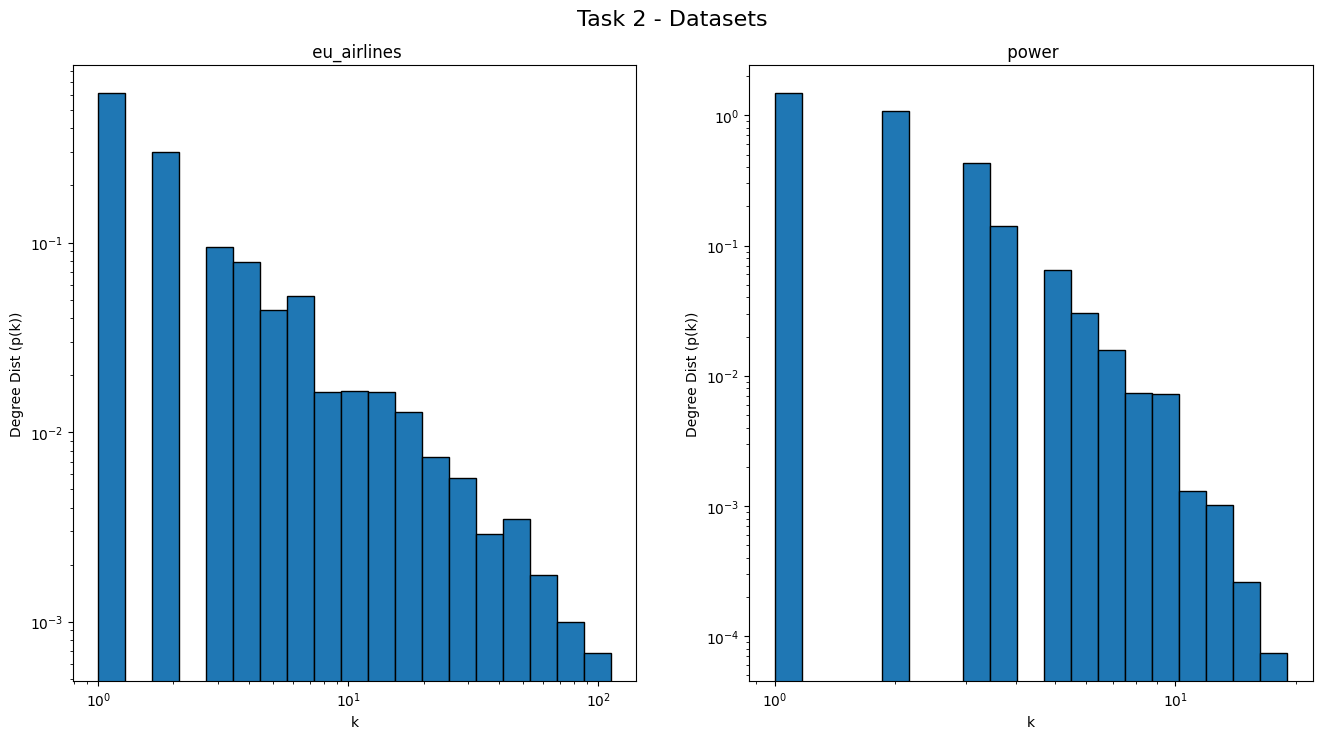

In [11]:
# plots the degree distribution against the degree using logarithmic binning
def plot_degree_dist(g, ax, title=None, log=True):
    degrees = list(dict(g.degree()).values())
    if log: 
        bins = np.logspace(np.log10(1), np.log10(max(degrees)), 20)    
        ax.set_xscale('log')
    else:
        bins = np.arange(0, max(degrees) + 1) - 0.5    

    ax.set_yscale('log')
    ax.hist(degrees, bins=bins, density=True, edgecolor='black') 

    set_ax_labels(ax, "k", "Degree Dist (p(k))", f"{title}")

# synthetic data erdos renyi
fig, axes = initialize_figure(1,2)

for i, (k, g) in enumerate(er_graphs.items()):
    plot_degree_dist(g, axes[i], title=f"n = 1000; k = {k}", log = False)

fig.suptitle("Task 2 - Erdös-Renyi Degree Distributions", fontsize=16, y=0.95)

# synthetic data barabasi_albert_graph
fig, axes = initialize_figure(1,2)

for i, (m, g) in enumerate(ba_graphs.items()):
    plot_degree_dist(g, axes[i], title=f"n = 1000; m = {m}")

fig.suptitle("Task 2 - Barabási-Albert Degree Distributions", fontsize=16, y=0.95)

clean_figure(fig, axes, len(ba_graphs), len(axes))

# datasets
fig, axes = initialize_figure(1,2)

for i, g in enumerate(data_lst):
    plot_degree_dist(g, axes[i], title=f"{data_names[i]}")

fig.suptitle("Task 2 - Datasets", fontsize=16, y=0.95)

## Task 3
Plot the size of the largest connected component as a function of removed edges and nodes in two scenarios for the synthetic graphs and the real networks in the datasets:
- Random attacks (failures)
- Targeted attacks (degree centrality and betweenness centrality)

### Comments
The majority of the measures (i.e. all except betweenness centrality) are computed using networkx. In order to speed up the computation of the betweenness and keep code readability, a different attack_function leveraging the i_graph library is implemented.

In [45]:
def size_largest_cc(G):
    try: 
        return len(max(nx.connected_components(G), key=len))
    except Exception as e:       
        return 0

def random_attack_node(g):
    return random.choice(list(g.nodes))

def random_attack_edge(g):
    return random.choice(list(g.edges))

def degree_centrality_attack(g):
    degrees = dict(g.degree())
    return max(degrees, key=degrees.get)


def attack(g, attack_function):
    g_copy = g.copy()
    N = g_copy.number_of_nodes()
    p0 = size_largest_cc(g_copy)
    removed_nodes = [(0, 1)]  
    j = 0
    while len(g_copy.nodes) > 0:
        node = attack_function(g_copy)
        g_copy.remove_node(node)
        j += 1

        f = j / N
        largest_cc_size = size_largest_cc(g_copy)
        pf_p0 = largest_cc_size / p0
        removed_nodes.append((f, pf_p0))

    x = [item[0] for item in removed_nodes]
    y = [item[1] for item in removed_nodes]
    return x, y

def attack_edges(g, attack_function):
    g_copy = g.copy()
    N = g_copy.number_of_edges()
    p0 = size_largest_cc(g_copy)
    removed_edges = [(0, 1)] 
    j = 0
    while g_copy.number_of_edges() > 0:
        edge = attack_function(g_copy)
        g_copy.remove_edge(*edge)
        j += 1
        f = j / N
        largest_cc_size = size_largest_cc(g_copy)
        pf_p0 = largest_cc_size / p0
        removed_edges.append((f, pf_p0))

    x = [item[0] for item in removed_edges]
    y = [item[1] for item in removed_edges]
    return x, y

def attack_between(g):
    igg = ig.Graph.TupleList(g.edges(), directed=False)
    N = igg.vcount()
    try:
        largest_cc = max(len(component) for component in igg.connected_components())
    except Exception as e:
        largest_cc = 0
    p0 = largest_cc
    removed_nodes = [(0, 1)]
    j = 0

    with tqdm(total=N, desc='Attacking nodes', unit='node') as pbar:
        while igg.vcount() > 0:
            betweenness = igg.betweenness()
            max_betweenness_value = max(betweenness)
            node_to_remove = betweenness.index(max_betweenness_value)   
                     
            igg.delete_vertices(node_to_remove)
            j += 1
            pbar.update(1)

            f = j / N
            try:
                largest_cc = max(len(component) for component in igg.connected_components())
            except Exception as e:
                largest_cc = 0            
            pf_p0 = largest_cc / p0
            removed_nodes.append((f, pf_p0))


    x = [item[0] for item in removed_nodes]
    y = [item[1] for item in removed_nodes]
    return x, y


attack_strategies = [
    ('Random Node Removal', random_attack_node, 'Blues', 'node'),
    ('Random Edge Removal', random_attack_edge, 'Purples', 'edge'),
    ('Degree Centrality Attacks', degree_centrality_attack, 'Reds', 'node'),
    ('Betweenness Centrality Attacks', None, 'Greens', 'between'),
]

Random Node Removal
Graph k=1
Graph k=4
Random Edge Removal
Graph k=1
Graph k=4
Degree Centrality Attacks
Graph k=1
Graph k=4
Betweenness Centrality Attacks
Graph k=1


Attacking nodes: 100%|██████████| 609/609 [00:00<00:00, 6757.44node/s]


Graph k=4


Attacking nodes: 100%|██████████| 973/973 [00:04<00:00, 198.77node/s]


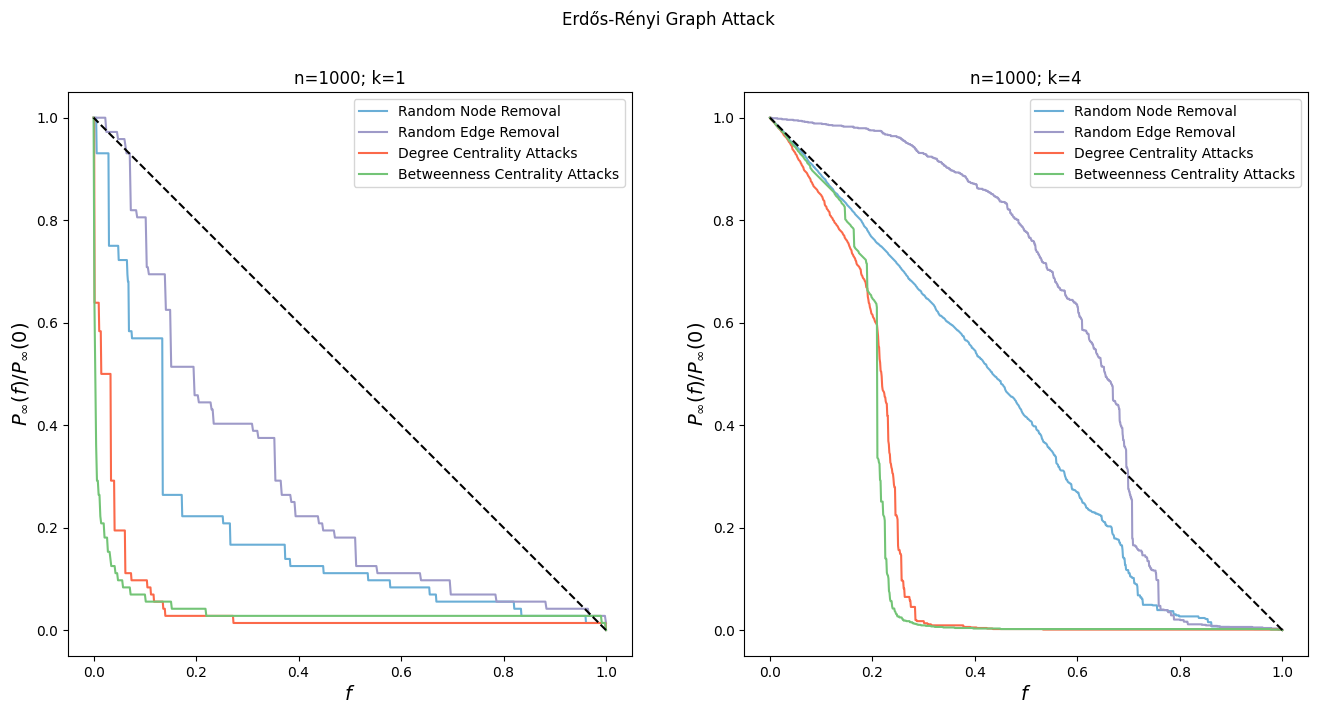

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cols = plt.get_cmap(cmap_name)
    
    for i, (k, g) in enumerate(er_graphs.items()):
        print(f"Graph k={k}")
        if type == 'node':
            x, y = attack(g, attack_function)
        elif type == 'between':
            x, y = attack_between(g)
        else: 
            x, y = attack_edges(g, attack_function)

        axes[i].plot(x, y, color=cols(0.5), label=f'{strategy_name}')
        axes[i].set_title(f'n=1000; k={k}')
        axes[i].set_xlabel(r'$f$', fontsize=14)
        axes[i].set_ylabel(r'$P_{\infty}(f)/P_{\infty}(0)$', fontsize=14)
        axes[i].legend(fontsize=10)


for ax in axes:
    ax.plot([1, 0], [0, 1], 'k--')
    ax.set_aspect('equal', adjustable='box')


plt.suptitle('Erdős-Rényi Graph Attack', y=0.95) 
plt.show()


Random Node Removal
Graph m=2
Graph m=4
Random Edge Removal
Graph m=2
Graph m=4
Degree Centrality Attacks
Graph m=2
Graph m=4
Betweenness Centrality Attacks
Graph m=2


Attacking nodes: 100%|██████████| 1000/1000 [00:02<00:00, 421.16node/s]


Graph m=4


Attacking nodes: 100%|██████████| 1000/1000 [00:07<00:00, 141.68node/s]


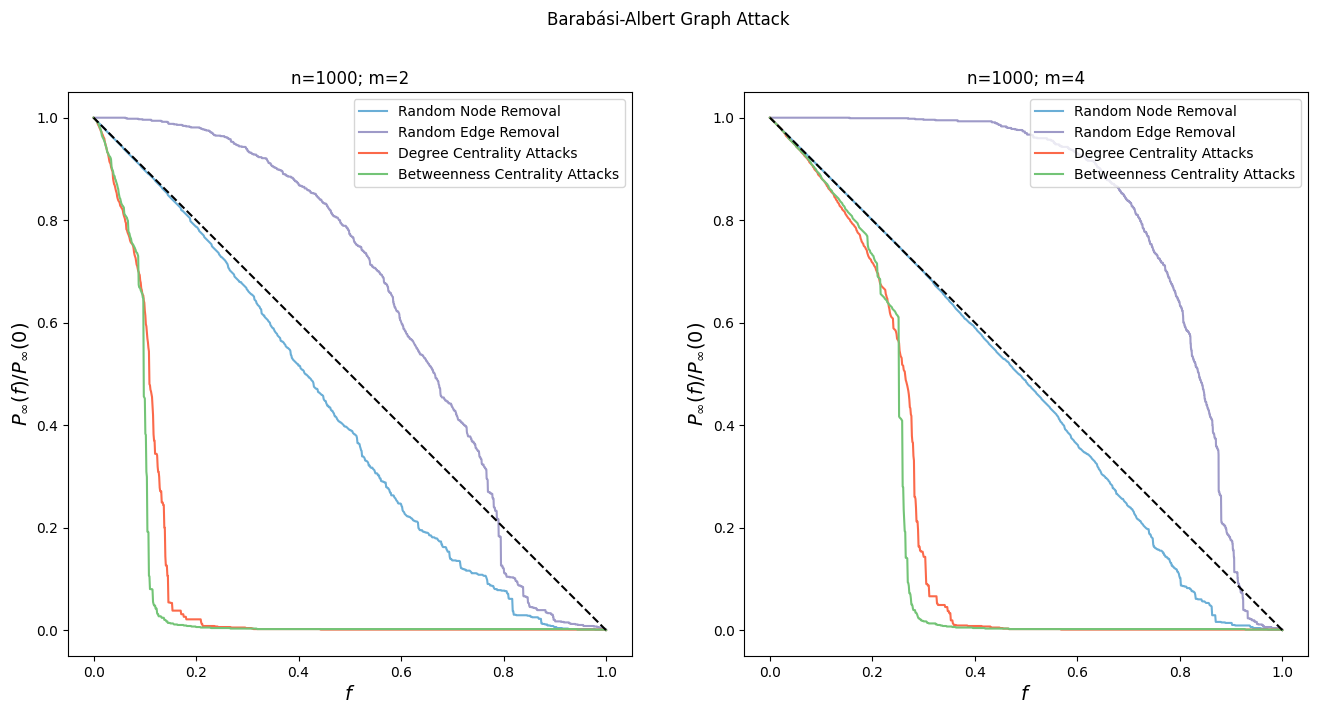

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cols = plt.get_cmap(cmap_name)
    
    for i, (m, g) in enumerate(ba_graphs.items()):
        print(f"Graph m={m}")
        if type == 'node':
            x, y = attack(g, attack_function)
        elif type == 'between':
            x, y = attack_between(g)
        else: 
            x, y = attack_edges(g, attack_function)

        axes[i].plot(x, y, color=cols(0.5), label=f'{strategy_name}')
        axes[i].set_title(f'n=1000; m={m}')
        axes[i].set_xlabel(r'$f$', fontsize=14)
        axes[i].set_ylabel(r'$P_{\infty}(f)/P_{\infty}(0)$', fontsize=14)
        axes[i].legend(fontsize=10, loc='upper right')


for ax in axes:
    ax.plot([1, 0], [0, 1], 'k--')
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Barabási-Albert Graph Attack', y=0.95) 
plt.show()

Random Node Removal
Graph eu_airlines
Graph power
Random Edge Removal
Graph eu_airlines
Graph power
Degree Centrality Attacks
Graph eu_airlines
Graph power
Betweenness Centrality Attacks
Graph eu_airlines


Attacking nodes: 100%|██████████| 417/417 [00:00<00:00, 1319.49node/s]


Graph power


Attacking nodes: 100%|██████████| 4941/4941 [00:27<00:00, 180.01node/s] 


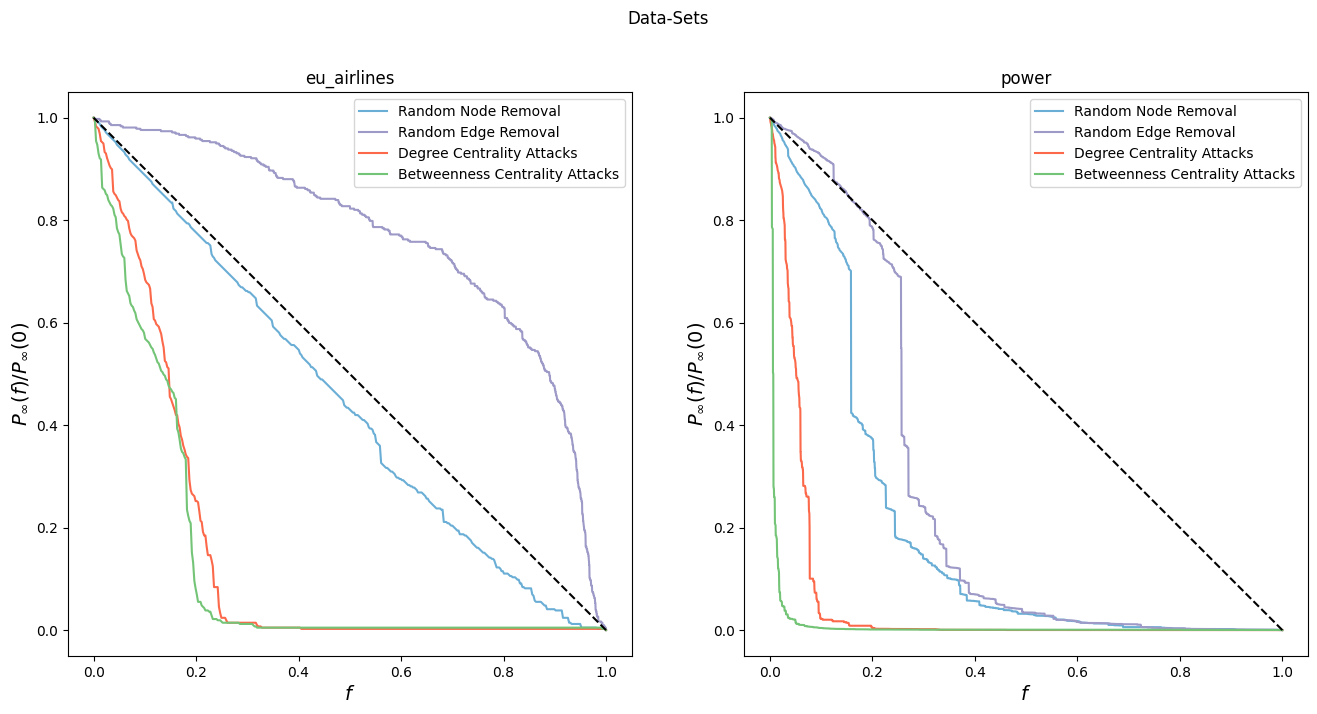

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cols = plt.get_cmap(cmap_name)
    
    for i, g in enumerate(data_lst):
        print(f"Graph {data_names[i]}")
        if type == 'node':
            x, y = attack(g, attack_function)
        elif type == 'between':
            x, y = attack_between(g)
        else: 
            x, y = attack_edges(g, attack_function)

        axes[i].plot(x, y, color=cols(0.5), label=f'{strategy_name}')
        axes[i].set_title(f'{data_names[i]}')
        axes[i].set_xlabel(r'$f$', fontsize=14)
        axes[i].set_ylabel(r'$P_{\infty}(f)/P_{\infty}(0)$', fontsize=14)
        axes[i].legend(fontsize=10, loc='upper right')


for ax in axes:
    ax.plot([1, 0], [0, 1], 'k--')
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Data-Sets', y=0.95) 
plt.show()

## Task 4
Comment the plots, using what we discussed in class.

### Erdös-Renyi Graphs

##### Preliminary Impressions
As to be expected, in both generation cases, i.e. k = {1,4}, the random attacks on both the nodes and edges are less effective in breaking down the network structure, compared to the targeted attacks on degree centrality and betweenness centrality. Since these graphs' degree distributions are approximated by a poission distribution, we anticipate random attacks to be more effective on ER graphs than on SF networks, and targeted attacks to be less effective due to the minimal "hub prevalence".

##### Random attacks
- Edge attacks in both cases appear to be the least effective attack method, thus both networks are most resistant to those. However, as theory predicts, the critical points should be equivalent ($f_c^{\text{node}} = f_c^{\text{edge}}$). This holds empirically: the networks are less vulnerable to edge attacks in the subcritical phase, however, as $f \rightarrow f_c$, $ \frac{p_{\infty}(f)}{p_{\infty}(0)}$ in node removal $= \frac{p_{\infty}(f)}{p_{\infty}(0)}$ in edge removal.
- For Erdös-Renyi graphs, the following holds: $\langle k^2 \rangle = \langle k \rangle (\langle k \rangle + 1)$; thus $f_c^{\text{ER}}$ is finite, and the ER networks should always be able to be broken apart with the removal of a finite fraction of nodes. This yields $f_c^{\text{ER}} = 1 - \frac{1}{\langle k \rangle}$:
    - By theory we find: $f_c^{\text{ER}} = 0$ for $k=1$ and $f_c^{\text{ER}} = \frac{3}{4}$ for $k=4$.
    - Empirically, we can replicate these findings. For $k=1$, the critical point is difficult to see, since the network is in the phase transition with the removal of the first node, hence what we can observe is only the transition of the critical to the supercritical phase. On the other hand, for $k=4$, the transition at 0.75 can be more easily distinguished, where the network transitions from the subcritical to the supercritical state.
- This is inline with the percolation theory discussed in the lecture. The removal of few nodes generally has only limited impact on network integrity. However, at the critical threshold $f_c$ the phase transition breaks the network into fragmented pieces.

##### Targeted Attacks

- Since the targeted attacks focus on relatively "important" nodes, we expect these strategies to be more efficient ("Important" as a notion of the defined attacking strategy)
- This expectation is backed by the empirical findings. Where $f_c$ for both degree centrality and betweenness centrality is significantly lower than their random counterparts.
- In terms of the ER graphs, conclusively distinguishing whether the networks deteriorate faster under degree centrality attacks or betweenness centrality attacks is difficult. A slight edge can be given to betweenness centrality attacks, however, given that betweenness centrality is a global measure, the computational edge of the degree centrality can be used to argue for the effectiveness thereof.


### Barabasi-Albert Graphs

##### Preliminary Impressions
Again, random attack are less effective than the targeted approaches. In contrast to ER graphs, the difference is more pronounced. Since Barabasi-Albert graphs are SF, this comes as no surprise, since the power law degree distribution helps to reduce the effect of random failures, as hubs are hardly ever affected. However, if these networks are subject to targeted attacks, theory stipulates that it should have a greater effect on the overall network integrity.

##### Random Attacks
- The preliminary findings are confirmed by the simulated BA graphs, with one crucial caveat. Scale-free graphs are indeed (more) resistant to random attacks iff $\gamma < 3$, with $p(k) \propto k^{-\gamma}$.
- In these cases, and those in the simulated examples, there does not exist a $f_c$ at which the connected component breaks apart, hence, the node attack (and by extension the edge attacks) have only little effect.
- It is worth noting that $f_c \rightarrow 1$ is an asymptotic property for $N \rightarrow \infty$, that allows us to understand the deviation from the "optimal/ linear" deterioration of the network under attack. 


##### Targeted Attacks
- We predicted that the SF networks deteriorate faster when attacked with a targeted approach, since "important" nodes or hubs, here with high degree or betweenness centrality, are core to the functionality and their existence is comparably rare (power-law cause by preferential attachment), thus $f_c^{SF-targeted}$ < $f_c^{ER-targeted}$

### Data-Sets

##### EU Airlines
The EU Airlines network with its SF distribution shows strong resilience against random attacks. With $f_c^{between} \approx 0.22$ and $f_c^{degree} \approx 0.25$ the network is also somewhat resistant to targeted attacks. This likely highlights redundancies in the network, caused by multiple airlines serving the same routes, owed to economic potential, as we have already outlined in previous assignments. However, few crucial carriers still appear to drive the core functionality of the full network, thus creating some vulnerabilities to more targeted attacks.


##### Power Grid
The power grid network exhibits few interesting properties. For one, it appears to be overall a fragile structure, susceptible to both random and targeted attacks. While $f_c^{rand} \approx 0.38$ allows for some crucial resistance to random failure, $f_c^{between} \approx 0.05$ and $f_c^{degree} \approx 0.1$ indicates the prevalence of few network crucial nodes, that if attacked, hold the ability to cause a network breakdown. 


##### Comparison
The power grid network appears to exhibits great centralization, with essential nodes bearing significant responsibility for its functionality. This centralization, that is likely due to technical and economical considerations, inherently limits redundancy, making the network vulnerable to targeted attacks on critical nodes, defined by their high betweenness or degree centrality.
The EU Airlines network, on the other hand, demonstrates less centralization, with connectivity more evenly distributed across nodes. This distribution provides higher redundancy, enabling the network to maintain large partial functionality even when high-centrality nodes are removed, thus displaying a more robust structure in response to targeted attacks.
In short, $f_c^{power}$ is significantly lower than $f_c^{airlines}$ making it more prone to network wide failure.

##### Additional Remark
Throughout the analysis, the betweenness centrality attacks demonstrate the overall highest effectiveness in deteriorating a network's functionality. One crucial limitation, which we already teased in the section on Erdös Renyi graphs, is the computational complexity of the betweenness centrality. The local property of degree centrality has also proven effective in attacking networks, and depending on network size, latter might be the more effective attack method considering the computational cost trade-off.



